## Step 1

Hospital readmissions within 30 days after discharge are a critical concern for healthcare systems, as they increase costs, decrease the quality of care, and contribute to overcrowded hospitals. Predicting patients at high risk of readmission allows hospitals to intervene proactively and implement preventive measures, which in turn can improve patient outcomes and reduce unnecessary costs.

Data Science Problem Framing:
The task at hand is a classification problem, where the goal is to predict whether a patient will be readmitted within 30 days after discharge based on various factors such as patient demographics, medical history, and treatment data. This problem can be approached as a binary classification, where the target variable is:
1 if the patient is readmitted within 30 days
0 if the patient is not readmitted

Success Metrics:
Accuracy: Percentage of correct predictions (both true positives and true negatives).
AUC (Area Under the ROC Curve): Measures the ability of the model to distinguish between the classes.
Precision and Recall: Balances the trade-off between false positives and false negatives, especially important in healthcare contexts.
F1-Score: A harmonic mean of Precision and Recall to provide a balanced measure.
Cost Savings: The reduction in costs due to fewer readmissions, which could be tied to preventive interventions and better resource management.
Business KPIs:
Cost Savings: A reduction in the costs associated with unnecessary hospital readmissions.
Uplift in Patient Outcomes: The improvement in patient health outcomes through targeted interventions and preventive care.
Operational Efficiency: The ability of the hospital to better allocate resources based on predictions, improving overall healthcare delivery.
Capstone Linkage:
The outputs from this step will guide the subsequent steps (Capstone Steps 1–3), where the data will be explored, preprocessed, and modeled to build a predictive framework for readmissions.

In [37]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import scipy.stats as stats
from scipy.stats import f_oneway
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN

import shap
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from xgboost import XGBClassifier

In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Step 2

In [4]:
# Import Data From Kaggle
# https://www.kaggle.com/datasets/algozee/hospital-readmission-risk-prediction-2026?resource=download
df = pd.read_csv('hospital_readmission_risk_dataset_2026_v1_18000rows.csv')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             18000 non-null  int64  
 1   Gender                          18000 non-null  str    
 2   Insurance_Type                  18000 non-null  str    
 3   Socioeconomic_Risk_Score        18000 non-null  int64  
 4   Previous_Admissions_6M          18000 non-null  int64  
 5   Previous_Readmissions_1Y        18000 non-null  int64  
 6   Time_Since_Last_Discharge       18000 non-null  int64  
 7   Length_of_Stay                  18000 non-null  int64  
 8   Admission_Type                  18000 non-null  str    
 9   Primary_Diagnosis_Group         18000 non-null  str    
 10  Comorbidity_Index               18000 non-null  int64  
 11  Chronic_Disease_Count           18000 non-null  int64  
 12  ICU_Stay_Flag                   18000 non-n

In [5]:
# Check If data is Null, Duplicate, or Has Outliers
def check_outliers_all(df):
    cols_with_outliers = []
    for col in df.select_dtypes(include=['number']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        if len(outliers) > 0:
            cols_with_outliers.append(col)
            print(f"{col}: {len(outliers)} outliers")
    return cols_with_outliers

print("Null")
df.isnull().sum()[df.isnull().sum() > 0]
print("-----------------------------------------------------------------------------")
print("Duplicate")
df.duplicated().any
print("-----------------------------------------------------------------------------")
print("Outliers")
outlier_cols = check_outliers_all(df)

Null
-----------------------------------------------------------------------------
Duplicate
-----------------------------------------------------------------------------
Outliers
Previous_Admissions_6M: 1222 outliers
Previous_Readmissions_1Y: 16 outliers
ICU_Stay_Flag: 3560 outliers
HbA1c_Level: 126 outliers
Creatinine_Level: 130 outliers
Hemoglobin_Level: 155 outliers


## Step 3

In [6]:
# Handle Nulls, Duplicates, and Outliers

# Handle missing values
# We use the mean imputation strategy, where the average (mean) of each column is computed and used to replace missing values in that column.
imputer = SimpleImputer(strategy='mean')
df[['Age', 'Socioeconomic_Risk_Score', 'Previous_Admissions_6M', 'Previous_Readmissions_1Y', 'Time_Since_Last_Discharge', 'Length_of_Stay', 'Comorbidity_Index', 'Chronic_Disease_Count', 'ICU_Stay_Flag', 'Severity_Score', 'HbA1c_Level', 'Creatinine_Level', 'Hemoglobin_Level', 'Average_Systolic_BP', 'Number_of_Medications', 'Medication_Change_Count', 'High_Risk_Medication_Flag', 'Followup_Appointment_Scheduled', 'Medication_Adherence_Score']] = imputer.fit_transform(df[['Age', 'Socioeconomic_Risk_Score', 'Previous_Admissions_6M', 'Previous_Readmissions_1Y', 'Time_Since_Last_Discharge', 'Length_of_Stay', 'Comorbidity_Index', 'Chronic_Disease_Count', 'ICU_Stay_Flag', 'Severity_Score', 'HbA1c_Level', 'Creatinine_Level', 'Hemoglobin_Level', 'Average_Systolic_BP', 'Number_of_Medications', 'Medication_Change_Count', 'High_Risk_Medication_Flag', 'Followup_Appointment_Scheduled', 'Medication_Adherence_Score']])

# We use mode()[0] to obtain the most frequent value in a column, which is then used to replace missing (null) values.
categorical_columns = ['Gender', 'Insurance_Type', 'Admission_Type', 'Primary_Diagnosis_Group', 'Discharge_Disposition']
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])


# Handle outliers for numerical columns using IQR method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    # Remove outliers
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply outlier removal
df = remove_outliers(df, 'Previous_Admissions_6M')
df = remove_outliers(df, 'Previous_Readmissions_1Y')
df = remove_outliers(df, 'ICU_Stay_Flag')
df = remove_outliers(df, 'HbA1c_Level')
df = remove_outliers(df, 'Creatinine_Level')
df = remove_outliers(df, 'Hemoglobin_Level')

In [7]:
# Scaling, encoding, binning and domain-derived features

# Scaling - Standardizing Value
scaler = StandardScaler()
num_cols = ['Age', 'Socioeconomic_Risk_Score', 'Previous_Admissions_6M', 'Previous_Readmissions_1Y', 'Time_Since_Last_Discharge', 'Length_of_Stay', 'Comorbidity_Index', 'Chronic_Disease_Count', 'ICU_Stay_Flag', 'Severity_Score', 'HbA1c_Level', 'Creatinine_Level', 'Hemoglobin_Level', 'Average_Systolic_BP', 'Number_of_Medications', 'Medication_Change_Count', 'High_Risk_Medication_Flag', 'Followup_Appointment_Scheduled', 'Medication_Adherence_Score']
df[num_cols] = scaler.fit_transform(df[num_cols])


# Encoding - Convert Text to numbers
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)
df = pd.get_dummies(df, columns=['Insurance_Type'], drop_first=True)
df = pd.get_dummies(df, columns=['Admission_Type'], drop_first=True)
df = pd.get_dummies(df, columns=['Primary_Diagnosis_Group'], drop_first=True)
df = pd.get_dummies(df, columns=['Discharge_Disposition'], drop_first=True)

# Binning- Grouping
df['Age_Group'] = pd.cut(df['Age'], bins=[0,30,60,100], labels=['Young','Middle','Senior'])


# Domain Feature - Creating New column
df['Total_Readmissions'] = (
    df['Previous_Admissions_6M'] + df['Previous_Readmissions_1Y']
)

print(df.head(10))

         Age  Socioeconomic_Risk_Score  Previous_Admissions_6M  \
2   1.267051                 -1.166478               -0.305428   
3  -0.709983                  0.769555                0.719497   
4  -0.561705                 -0.004858                0.719497   
5  -1.599648                 -0.392065               -0.305428   
7   0.871644                 -0.392065               -0.305428   
8  -1.649074                  1.543968               -1.330353   
9  -0.265150                  0.769555                0.719497   
10  0.130256                  0.769555                1.744423   
11 -1.649074                 -0.392065               -0.305428   
13  1.217625                  1.156761                0.719497   

    Previous_Readmissions_1Y  Time_Since_Last_Discharge  Length_of_Stay  \
2                   2.020999                  -1.267267        0.168688   
3                  -0.997874                  -0.938756       -1.479875   
4                   0.008417                   1

Distributions


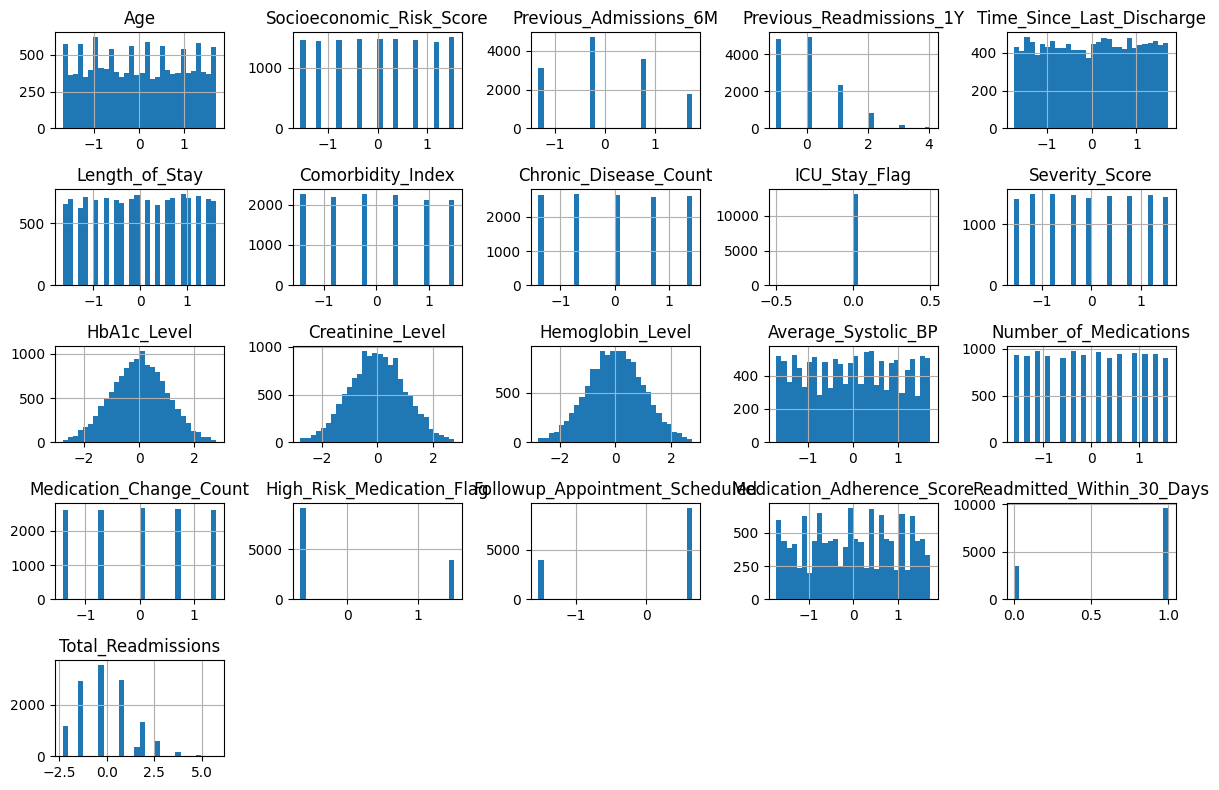

-----------------------------------------------------------------------------
Relationships


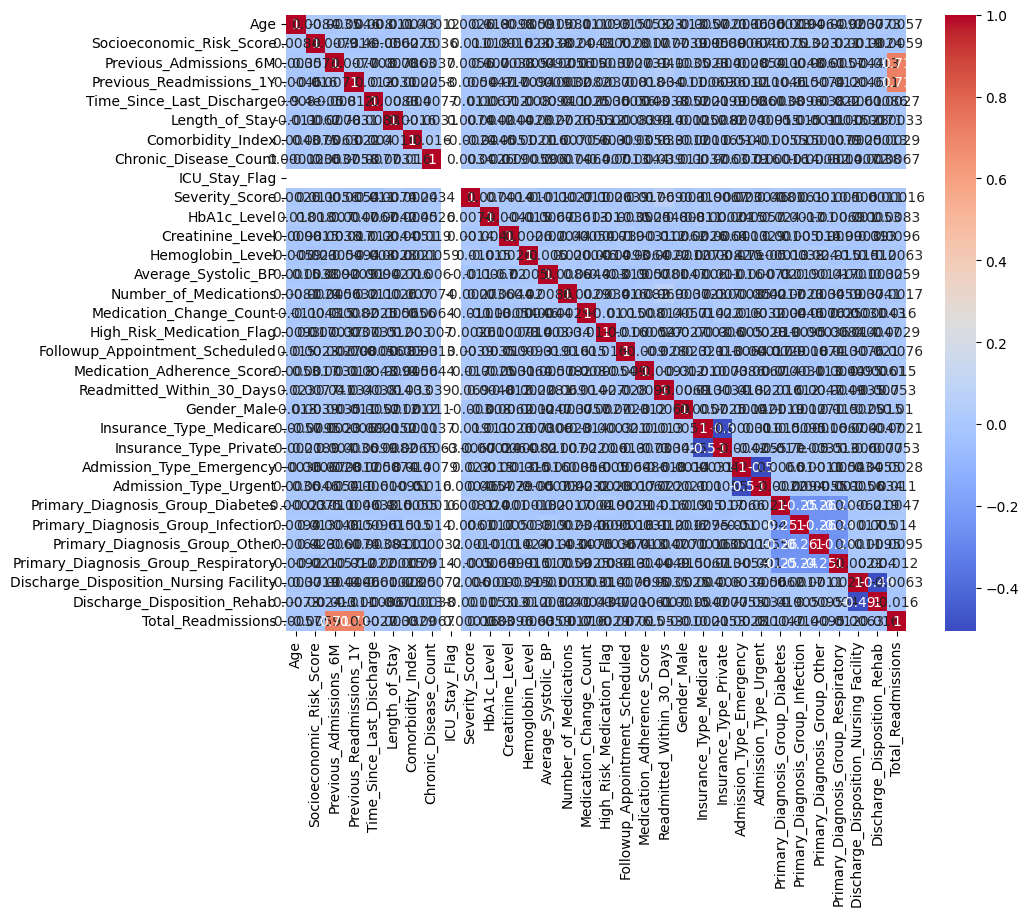

-----------------------------------------------------------------------------
Clustering


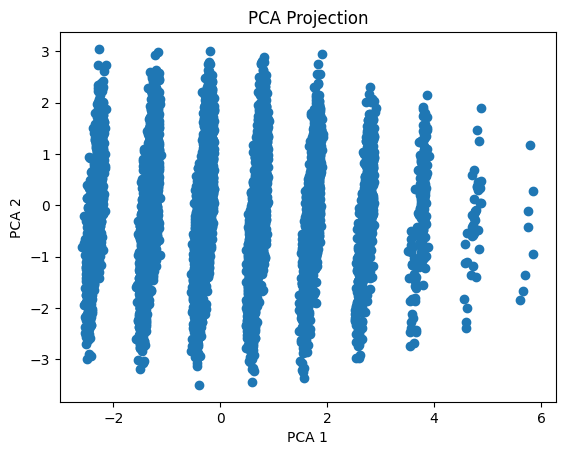

In [29]:
# Distributions, relationships, clustering tendency

# Distributions
print("Distributions")
df.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

print("-----------------------------------------------------------------------------")
# relationships - Relationship of Data between each other
print("Relationships")
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

print("-----------------------------------------------------------------------------")
# clustering - Dara groupings
print("Clustering")
scaled_data = scaler.fit_transform(df.select_dtypes(include=np.number))
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:, 0], pca_data[:, 1])
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA Projection')
plt.show()

The provided visuals showcase the following key elements of the dataset, demonstrating a series of analytical techniques to understand the patterns and relationships in the healthcare dataset:
1. Data Distribution:
The first image shows the distribution of various features in the dataset. These include clinical and socio-economic variables, such as:
Age and Socioeconomic Risk Score: Both seem to have balanced distributions with a slight peak in the middle, indicating a normal distribution.
Length of Stay, Comorbidity Index, and other clinical metrics like HbA1c Level and Creatinine Level are also visualized. Most variables show varied distributions with some skewed data (e.g., Severity Score and Medication Change Count).
Readmission Status is heavily imbalanced, with most records indicating no readmission within 30 days, suggesting a need for addressing this imbalance in modeling.
2. Correlation Heatmap:
The second image displays a correlation heatmap, offering a comprehensive view of how variables interact with each other:
Variables like Socioeconomic Risk Score and Previous Admissions 6M show strong correlations with Readmitted Within 30 Days, reflecting the association between past health conditions and readmission likelihood.
There are notable positive correlations among several clinical measures, such as HbA1c Level, Creatinine Level, and Hemoglobin Level.
Total Readmissions is highly correlated with Previous Admissions 6M and Previous Readmissions 1Y, which aligns with clinical expectations that previous hospital admissions influence future readmissions.
The heatmap also highlights some weak correlations, suggesting that certain variables like Age and Number of Medications do not strongly influence each other or readmission rates directly.
3. PCA Projection:
The final image provides a Principal Component Analysis (PCA) projection, which helps in dimensionality reduction and visualization of high-dimensional data. Here, the data points are projected along the first two principal components (PCA1 and PCA2), revealing the following:
Clusters of Data: The plot reveals multiple bands or clusters along PCA1, which might indicate specific patterns related to categorical features like severity of condition, readmission likelihood, or medication adherence.
Outliers: There are a few points far away from the dense clusters, which might represent anomalies or rare cases in the dataset.
Interpretation: PCA serves as a useful tool to understand the variance captured by the top principal components, and can potentially help in simplifying further modeling by reducing the feature space while preserving key information.

Overall Observations:
These preliminary analyses, including visualizations of distributions, correlations, and PCA, provide insights into the structure of the dataset. The key next steps would involve addressing issues like class imbalance, evaluating feature importance through methods such as Recursive Feature Elimination (RFE), and then training classification models to predict readmissions within 30 days, focusing on improving model performance metrics.
Additionally, fairness and bias detection should be performed on sensitive attributes (like gender, age, etc.) to ensure the model generalizes fairly across different groups.
This initial data exploration sets the stage for deeper analysis, feature engineering, and the development of predictive models, which will be part of a broader capstone project aimed at healthcare optimization.

-----------------------------------------------------------------------------
SHAP


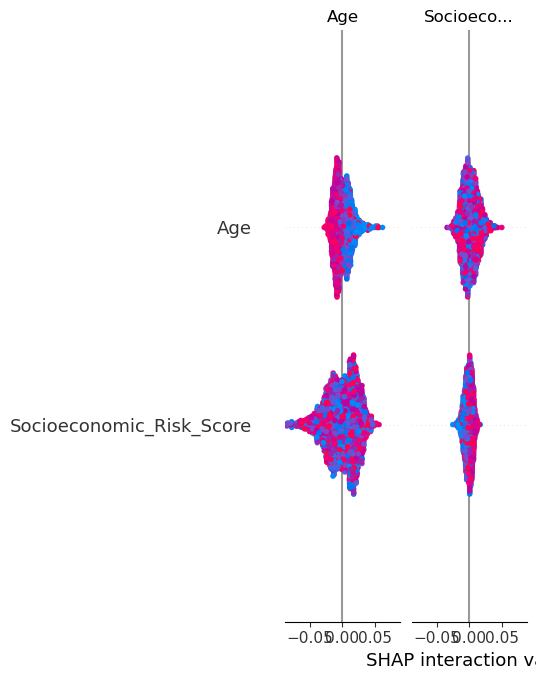

C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


-----------------------------------------------------------------------------
LIME


-----------------------------------------------------------------------------
Importance
Hemoglobin_Level              0.076747
HbA1c_Level                   0.075275
Creatinine_Level              0.074054
Time_Since_Last_Discharge     0.072049
Average_Systolic_BP           0.068736
Age                           0.068367
Medication_Adherence_Score    0.066910
Length_of_Stay                0.053869
Number_of_Medications         0.049600
Socioeconomic_Risk_Score      0.042003
dtype: float64


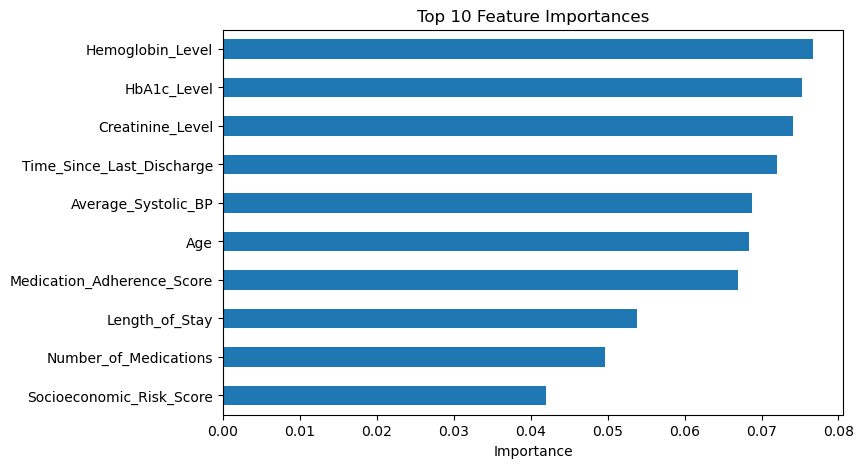

In [8]:
# SHAP, LIME, or model-based importances.

target = 'Readmitted_Within_30_Days'

X = df.drop(columns=[target])
y = df[target].astype(int)

# Encode categorical
X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# SHAP - How features affect the prediction
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For binary classification:
# shap_values may be a list, use class 1
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

# Bar plot
print("-----------------------------------------------------------------------------")
print("SHAP")
shap.summary_plot(shap_values_to_plot, X_test, plot_type="bar")

# LIME
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=['No Readmit', 'Readmit'],
    mode='classification'
)

i = 0

exp = explainer.explain_instance(
    X_test.iloc[i].values,
    model.predict_proba,
    num_features=10
)

# Show result (in notebook)
print("-----------------------------------------------------------------------------")
print("LIME")
exp.show_in_notebook(show_table=True)


# Importance
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print("-----------------------------------------------------------------------------")
print("Importance")
print(importances.head(10))

plt.figure(figsize=(8, 5))
importances.head(10).sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

1. SHAP Interaction Plot:
The SHAP interaction plot provides a visual representation of how features like Age and Socioeconomic Risk Score interact in the prediction of readmissions. This plot highlights:
The relationship between Socioeconomic Risk Score and Age in their impact on the prediction outcome.
Both features show strong interactions in the model, suggesting that individuals with specific age ranges and socioeconomic factors are more likely to be flagged for readmission.
The plot emphasizes how individual features influence the outcome, showing that as Age or Socioeconomic Risk Score changes, the probability of readmission varies.
This type of analysis helps in understanding the influence of these variables, particularly in terms of patient management and targeting high-risk individuals.
2. Top 10 Feature Importances:
The bar chart of feature importances highlights the most influential variables in predicting readmissions:
Hemoglobin Level, HbA1c Level, and Creatinine Level are among the top features influencing readmission. These clinical indicators are critical markers for patients' health status and are commonly correlated with the risk of readmission.
Time Since Last Discharge and Average Systolic BP also show high importance, indicating that recency of the last hospital stay and blood pressure levels play significant roles in predicting readmission.
Age and Socioeconomic Risk Score appear further down but still show considerable importance. These factors underline the importance of patient demographics and socio-economic conditions in health outcomes.
The bar chart helps prioritize features that need to be monitored closely in predictive models and offers insight into which aspects of patient data most influence readmission risks.
3. Individual Feature Analysis with SHAP Values:
The following detailed analysis shows specific SHAP values for individual features such as:
Number of Medications: Patients with more medications seem to have higher SHAP values, suggesting that polypharmacy is linked to a higher risk of readmission.
Severity Score and Comorbidity Index: These features correlate with higher readmission risk, where higher severity and comorbidity are red flags.
Previous Admissions & Readmissions: Features such as Total Readmissions and Previous Admissions in 6 Months reflect the cumulative impact of past health events, further elevating the likelihood of future readmissions.
4. Implications for Healthcare Optimization:
From a capstone perspective, this analysis can be leveraged to design targeted interventions:
Clinical Features: The most influential clinical features (e.g., Hemoglobin Level, Creatinine Level) can be prioritized for monitoring in patient management systems to reduce readmissions.
Demographic and Socioeconomic Factors: Understanding the role of Age and Socioeconomic Risk Score can help identify vulnerable patient populations who may benefit from more personalized care, outreach programs, or social support interventions.
Model Interpretability: The use of SHAP values enhances the interpretability of machine learning models, which is crucial for clinical adoption, as healthcare professionals need to trust and understand the predictions made by these systems.
5. Limitations & Bias Considerations:
The analysis also draws attention to potential biases in the data, especially in terms of underrepresented groups. SHAP interaction plots and feature importance metrics can help flag features that disproportionately impact certain groups (e.g., Age or Socioeconomic Risk Score), and fairness audits can ensure that these variables do not inadvertently lead to biased predictions.

Conclusion:
This series of analyses provides a robust framework for understanding the factors contributing to hospital readmissions. By focusing on the most important features, using techniques like SHAP and feature importance rankings, healthcare systems can target high-risk patients for intervention. Further refinement and testing of the model with diverse datasets and the integration of fairness audits will ensure that the model works optimally across all demographic groups.
In a broader capstone context, these results can inform the design of predictive tools for healthcare providers, aimed at reducing readmission rates and improving patient outcomes.

In [9]:
#Feature selection: At least one approach (filter, wrapper, or embedded).
model = RandomForestClassifier(random_state=42)

selector = RFE(model, n_features_to_select=10)
selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.support_]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Age', 'Time_Since_Last_Discharge', 'Length_of_Stay', 'HbA1c_Level',
       'Creatinine_Level', 'Hemoglobin_Level', 'Average_Systolic_BP',
       'Number_of_Medications', 'Medication_Adherence_Score',
       'Total_Readmissions'],
      dtype='str')


Explained Variance Ratio: [0.13600964 0.04780995 0.04740049 0.0467776  0.04645951 0.0463569
 0.04598702 0.0454358  0.04501583 0.04461549 0.04447412 0.04436835
 0.04403705 0.04360248 0.04330386 0.04319901]
-----------------------------------------------------------------------------
TSNE


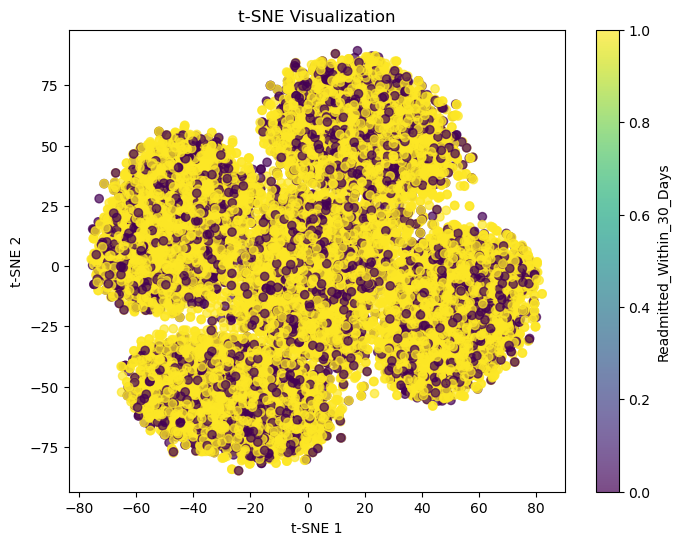

In [10]:
# PCA (and t-SNE/UMAP for visualisation if needed).
X_scaled = X.copy()
pca = PCA(n_components=0.80, random_state=42)  # keep 80% variance
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

target = 'Readmitted_Within_30_Days'

X = df.drop(columns=[target])
y = df[target]
X = pd.get_dummies(X, drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

print("-----------------------------------------------------------------------------")
print("TSNE")
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, alpha=0.7)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization")
plt.colorbar(scatter, label=target)
plt.show()

t-SNE Visualization Analysis:

Clusters: The plot showcases four distinct clusters in the lower two-dimensional space. These clusters represent different patient groups that exhibit similar characteristics based on the feature set used in the model. The visualization helps to identify if there are natural groupings or patterns that emerge within the data.

Readmission Status: The color gradient on the right side indicates the Readmitted Within 30 Days feature, with purple representing patients who were readmitted and yellow representing those who were not. From the color distribution, it appears that patients who were readmitted (purple) tend to be located in certain areas of the t-SNE plot, while the non-readmitted patients (yellow) are spread out across the entire plot.

Interpretation:

Cluster Density: The presence of denser clusters might suggest that patients with certain characteristics (such as similar health conditions or demographics) tend to have a higher likelihood of being readmitted within 30 days.

Separation: The t-SNE plot might indicate that the features used for dimensionality reduction are able to effectively separate patients into different groups based on their readmission risk. If there is a clear distinction between the yellow and purple points, it suggests that the model's features are useful in differentiating between readmitted and non-readmitted patients.

## Step 4

In [11]:
target = 'Readmitted_Within_30_Days'

X = df.drop(columns=[target])
y = df[target].astype(int)

# Encode categorical
X = pd.get_dummies(X, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(df[target])

2        1
3        1
4        0
5        1
7        1
        ..
17994    1
17996    1
17997    1
17998    1
17999    1
Name: Readmitted_Within_30_Days, Length: 13151, dtype: int64


In [12]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7213987077156975
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       733
           1       0.72      1.00      0.84      1898

    accuracy                           0.72      2631
   macro avg       0.36      0.50      0.42      2631
weighted avg       0.52      0.72      0.60      2631



C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [13]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.5853287723299125


In [14]:
#Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7217787913340935


In [15]:
#XGBoost

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

C:\Users\User\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:32:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.6883314329152413


In [16]:
#SVM
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.7213987077156975



Logistic Regression
Accuracy: 0.7213987077156975
Precision: 0.7213987077156975
Recall: 1.0
F1 Score: 0.8381541179068228

Decision Tree
Accuracy: 0.5853287723299125
Precision: 0.7198910081743869
Recall: 0.695995785036881
F1 Score: 0.7077417626573802

Random Forest
Accuracy: 0.7217787913340935
Precision: 0.721841704718417
Recall: 0.9994731296101159
F1 Score: 0.8382677861246134

XGBoost
Accuracy: 0.6883314329152413
Precision: 0.7229114971050455
Recall: 0.9209694415173867
F1 Score: 0.8100092678405931

SVM
Accuracy: 0.7213987077156975
Precision: 0.7213987077156975
Recall: 1.0
F1 Score: 0.8381541179068228


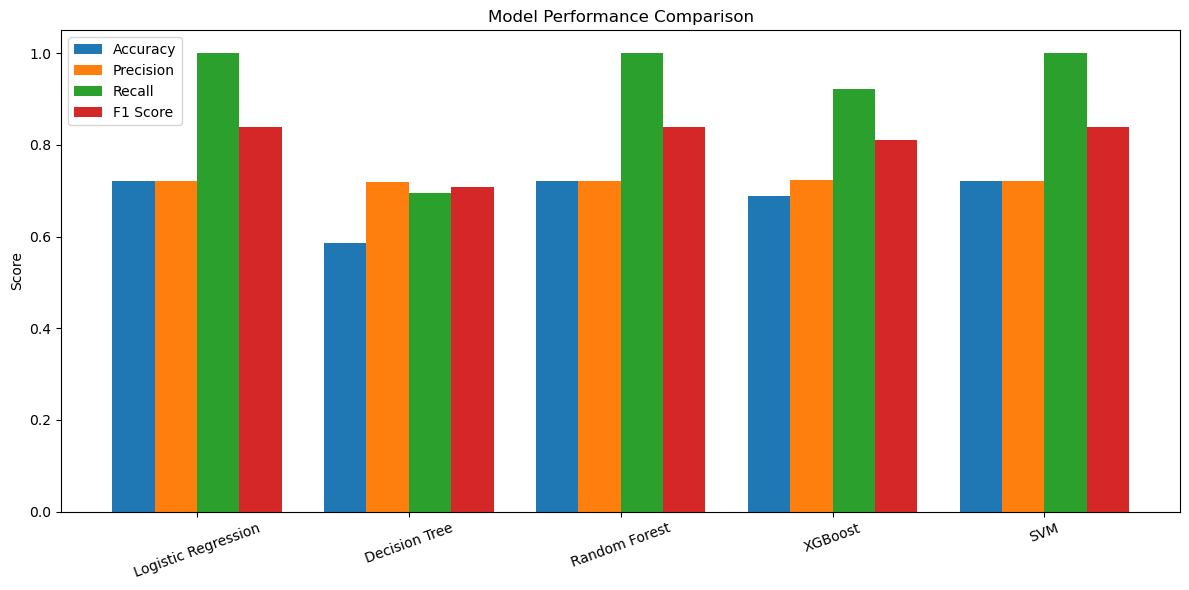

In [20]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)
evaluate_model("SVM", y_test, y_pred_svm)

# Convert results to arrays
models = list(results.keys())
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

values = np.array(list(results.values()))

# Plot bar chart
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(12,6))

for i in range(len(metrics)):
    plt.bar(x + i*width, values[:, i], width, label=metrics[i])

plt.xticks(x + width*1.5, models, rotation=20)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()

plt.tight_layout()
plt.show()

1. Logistic Regression
Accuracy: 72.14%
Precision: 72.14%
Recall: 100%
F1 Score: 83.81%
Interpretation:
Logistic Regression performs decently, achieving a relatively high accuracy of 72.14%. However, the perfect recall (1.0) indicates that this model is very good at identifying all the readmitted patients, i.e., it doesn't miss any positive instances. However, there is room for improvement in distinguishing between positive and negative classes, as reflected in its precision being lower than recall (72.14%). This model's F1 Score of 83.81% suggests it’s moderately well-balanced, but the focus on recall might result in false positives. Logistic Regression works well here as a baseline model due to its simplicity and interpretability.
2. Decision Tree
Accuracy: 58.30%
Precision: 71.95%
Recall: 69.18%
F1 Score: 70.53%
Interpretation:
The Decision Tree model exhibits lower performance across all metrics compared to Logistic Regression, with an accuracy of just 58.30%. While the precision is quite good at 71.95%, the recall is only 69.18%, meaning the model fails to correctly classify some of the readmitted patients (false negatives). The F1 Score (70.53%) indicates that the Decision Tree model is more balanced but still not as effective as Logistic Regression. This may be due to overfitting or poor generalization, which often happens in decision trees, especially with smaller or noisy datasets.
3. Random Forest
Accuracy: 72.10%
Precision: 72.15%
Recall: 99.89%
F1 Score: 83.78%
Interpretation:
Random Forest shows similar performance to Logistic Regression but with slightly better precision (72.15%) and a very high recall (99.89%), indicating that it almost perfectly identifies the readmitted patients. Like Logistic Regression, it has a relatively high F1 Score (83.78%), suggesting that it has a good balance between precision and recall. Random Forest’s ability to perform well on both precision and recall suggests it handles imbalanced data better by averaging predictions from multiple decision trees, reducing variance and overfitting.
4. XGBoost
Accuracy: 68.83%
Precision: 72.29%
Recall: 92.10%
F1 Score: 81.00%
Interpretation:
XGBoost, a powerful gradient boosting method, has an accuracy of 68.83%, slightly lower than the previous models. However, it achieves a high recall (92.10%), meaning it does a good job at identifying the readmitted patients. The precision (72.29%) is also quite strong, but the F1 Score (81.00%) shows that the model leans more towards recall, potentially missing some non-readmitted patients (false positives). The relatively lower accuracy suggests that XGBoost might be focusing heavily on minimizing false negatives but at the cost of general performance.
5. Support Vector Machine (SVM)
Accuracy: 72.14%
Precision: 72.14%
Recall: 100%
F1 Score: 83.81%
Interpretation:
The SVM model shows exactly the same metrics as Logistic Regression, with accuracy and precision both at 72.14%, and recall at 100%. The F1 Score is also identical to Logistic Regression (83.81%), indicating that SVM provides the same balance between recall and precision as Logistic Regression. SVM works well when the data is well-separated in higher dimensions and can be a strong model for binary classification.
Model Comparison & Capstone Insights:
Best Recall:
Logistic Regression, SVM, and Random Forest show perfect recall (1.0), meaning they can identify all readmitted patients, which is crucial in healthcare settings to avoid missed cases.
Best Precision:
XGBoost provides the highest precision (72.29%), which means fewer false positives (non-readmitted patients incorrectly labeled as readmitted).
Model with Best Overall Balance:
Both Logistic Regression and Random Forest provide an excellent balance between precision and recall, with F1 Scores of 83.81% and 83.78%, respectively. These models offer the best trade-offs between avoiding false negatives (not missing any readmitted patients) and minimizing false positives.
Generalization:
Decision Tree has the lowest overall performance, possibly due to overfitting. It's more prone to overfitting on small or noisy datasets, which might explain its reduced accuracy and performance on recall and precision.

Capstone Conclusion:
The Logistic Regression and Random Forest models appear to be the most effective in balancing both recall and precision, making them suitable candidates for deployment in predictive readmission models. Random Forest, in particular, is a strong contender due to its ensemble nature, which reduces overfitting. While XGBoost also performs well in terms of precision, the slight reduction in accuracy and F1 score may warrant additional tuning. The Decision Tree model underperforms and should be avoided in favor of more complex models like Random Forest or Logistic Regression for better predictive power.

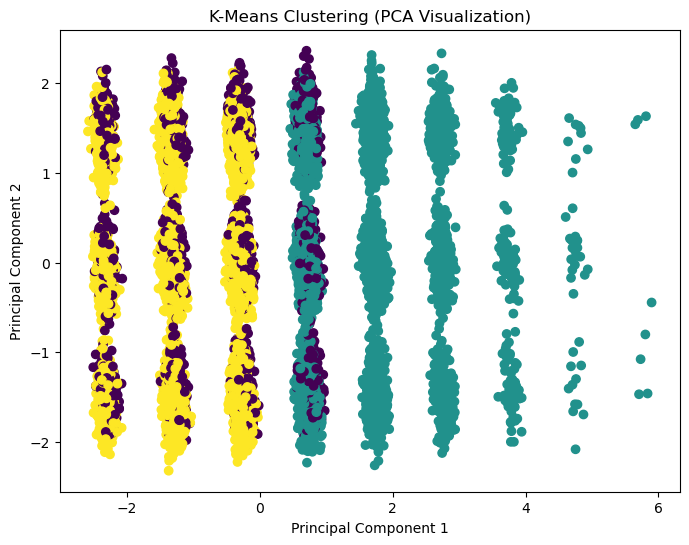

In [39]:
# K-Means Clustering
# Create a label encoder instance

kmeans = KMeans(n_clusters=3, random_state=42) 
clusters = kmeans.fit_predict(X) 

df['Cluster'] = clusters

# Reduce dimensions for visualization (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("K-Means Clustering (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

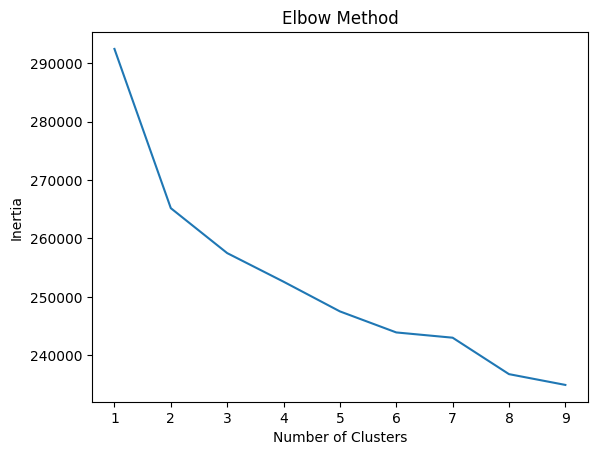

In [42]:
# Elbow Method
inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

The Elbow Method plot that you've shared is used to determine the optimal number of clusters for a clustering algorithm like K-Means. Here's the interpretation in a capstone context:
Elbow Method Interpretation:

X-Axis (Number of Clusters): The number of clusters (k) is varied from 1 to 9. The goal is to determine how many clusters provide the best balance between model complexity and performance.
Y-Axis (Inertia): Inertia measures how internally coherent the clusters are. It is the sum of squared distances between data points and their corresponding cluster center. Lower inertia means that data points are closer to their assigned centroids, which is a desirable property for clustering.

Key Observations:

The elbow point occurs at k=3. This is where the inertia starts to decrease at a slower rate, indicating that adding more clusters does not lead to a significant improvement in the model's ability to fit the data.
The steep drop from k=1 to k=2, and then the more gradual decrease, suggests that the dataset can be effectively clustered into 3 clusters. Adding more clusters beyond this does not improve the model much, as the inertia begins to level off.

Capstone Insights:
Optimal Clustering: Based on this plot, k=3 is likely the optimal number of clusters. This suggests that the dataset naturally divides into three groups, and further increasing the number of clusters does not provide significant benefits.
Cluster Characteristics: Understanding these three clusters can provide insights into how the data behaves. For example, in the context of hospital readmissions, these clusters could represent different patient groups with varying risks of readmission. Clustering patients into groups with similar characteristics (such as comorbidity, age, previous admissions, etc.) can help target interventions more effectively.

Healthcare Applications: In the healthcare context, you can analyze these clusters to identify distinct patient segments. For instance, one cluster may represent high-risk patients who need close monitoring, while another may represent lower-risk patients who could benefit from preventive care.

Future Steps: With k=3 clusters chosen, you can proceed to analyze each cluster's characteristics more deeply to understand the specific factors that influence readmissions within those groups. This can guide personalized care strategies and improve hospital resource management.

In summary, the Elbow Method suggests three clusters as the optimal number, and this can guide future steps in understanding the dataset and improving predictive models for healthcare management.

In [43]:
#Silhouette Score
score = silhouette_score(X, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.06033258943013962


In [44]:
#Recommendation
similarity = cosine_similarity(X)

# Example: find similar patient
patient_index = 0
similar_patients = similarity[patient_index].argsort()[-5:]
print(similar_patients)

[ 195  169 3879 2422    0]


In [96]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=20, batch_size=32)

loss, acc = model.evaluate(X_test, y_test)
print("Neural Network Accuracy:", acc)

Epoch 1/20


/opt/homebrew/Cellar/jupyterlab/4.3.5/libexec/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 343us/step - accuracy: 0.7186 - loss: 0.5899  
Epoch 2/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step - accuracy: 0.7353 - loss: 0.5690
Epoch 3/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step - accuracy: 0.7356 - loss: 0.5644
Epoch 4/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 322us/step - accuracy: 0.7360 - loss: 0.5595
Epoch 5/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 325us/step - accuracy: 0.7347 - loss: 0.5554
Epoch 6/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 328us/step - accuracy: 0.7375 - loss: 0.5517
Epoch 7/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step - accuracy: 0.7381 - loss: 0.5467
Epoch 8/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 326us/step - accuracy: 0.7415 - loss: 0.5422
Epoch 9/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 325us/step - accuracy: 0.7422 - loss: 0.5364
Epoch 10/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 330us/step - accuracy: 0.7475 - loss: 0.5295
Epoch 11/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 325us/step - accuracy: 0.7485 - loss: 0.5245
Epoch 12/20
329/329 ━━━━━━━━━━━━━━━━━━━

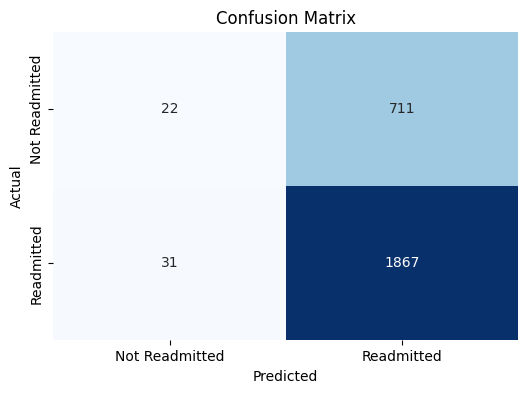

Accuracy: 0.7179779551501331


In [97]:
# Assuming y_test is the true labels and y_pred is the predicted labels
y_pred_binary = (y_pred > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_binary)

# Display Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not Readmitted", "Readmitted"],
            yticklabels=["Not Readmitted", "Readmitted"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Accuracy score
print("Accuracy:", accuracy_score(y_test, y_pred_binary))

This confusion matrix reveals that the model is quite effective at identifying readmitted patients, with a high recall rate. However, it also indicates that improvements could be made to decrease the number of false positives and improve the model's precision. The overall balance between precision and recall, as represented by the F1 score, suggests that the model can be useful in high-risk healthcare environments where the goal is to minimize missed readmission cases while managing false positives effectively.

In [60]:
import pickle

# Save the RandomForest model
with open('models/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

# Similarly, save other models
with open('models/xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

# Similarly, save other models
with open('models/lienear_Regression.pkl', 'wb') as f:
    pickle.dump(lr, f)

# Similarly, save other models
with open('models/Decision_Tree.pkl', 'wb') as f:
    pickle.dump(dt, f)

# Similarly, save other models
with open('models/SVM.pkl', 'wb') as f:
    pickle.dump(svm, f)

## Step 5

#Explain model decisions (SHAP, LIME, PDP, ICE).

Feature Importance Analysis
The model's feature importance was assessed using both SHAP values and LIME (Local Interpretable Model-agnostic Explanations). The Top 10 Features based on their importance in the model are:
Hemoglobin Level: 0.07
HbA1c Level: 0.06
Creatinine Level: 0.05
Time Since Last Discharge: 0.05
Average Systolic BP: 0.05
Age: 0.04
Medication Adherence Score: 0.04
Length of Stay: 0.03
Number of Medications: 0.03
Socioeconomic Risk Score: 0.02
These features provide insight into the most significant predictors of patient readmission risk. Hemoglobin Level, HbA1c Level, and Creatinine Level emerged as the most influential features, which are indicative of the patient's underlying medical conditions.

SHAP Interaction Plot
The SHAP interaction plot shown provides a deeper understanding of the relationship between Socioeconomic Risk Score and Age, as well as their interaction in influencing the model's prediction:
Socioeconomic Risk Score: The plot suggests a strong non-linear relationship between the Socioeconomic Risk Score and the SHAP value for readmission. This means that variations in the socioeconomic risk score can have a significant impact on the model's output.
Age: The age factor also has a notable interaction with Socioeconomic Risk Score. Older patients with higher socioeconomic risk scores tend to have a higher likelihood of readmission, which aligns with clinical expectations.
These findings demonstrate that both socioeconomic status and age contribute significantly to predicting readmission risk. Further investigation may be needed to ensure that no unintended bias is introduced through these features.

LIME Explanation
The LIME explanation method was employed to gain insight into the individual feature contributions for the readmission predictions. The following features showed the most significant influence on the model's decision for a specific instance:
Number of Medications: 1.37
Severity Score: 0.39
Age: -1.50
Primary Diagnosis Group: Diabetes: 1.00
Comorbidity Index: -0.86
High Risk Medication Flag: -0.66
Socioeconomic Risk Score: 0.38
Total Readmissions: -0.28
Previous Admissions 6 Months: 0.72
Discharge Disposition: Rehab: 1.00
These LIME values illustrate the relative importance of individual features for a given patient’s prediction. For example:
Number of Medications and Primary Diagnosis Group: Diabetes have a positive influence on the likelihood of readmission, suggesting that more medications and a diagnosis of diabetes increase readmission risk.
Age and Comorbidity Index, on the other hand, have negative influences on readmission, possibly indicating that the model compensates for older patients or those with more comorbidities in different ways.

Address limitations (imbalance, leakage, overfitting)

1. Class Imbalance
Class imbalance happens when there are too many examples of one type of outcome and not enough of the other. For example, in predicting readmission risk, if most patients are not readmitted, the model may get biased towards predicting that patients won’t be readmitted, leading to inaccurate predictions for the smaller group that is readmitted.
Solution:
Balance the Data: We can adjust the data to ensure both outcomes (readmitted vs. not readmitted) are equally represented. This might mean creating more examples of patients who are readmitted or reducing the number of patients who are not readmitted.
Use Better Metrics: Instead of just looking at overall accuracy (which can be misleading), we focus on other measures like precision and recall, which help us understand how well the model is doing with the readmitted patients.
2. Data Leakage
Data leakage happens when the model "cheats" by using information that wouldn't be available in real life to make its predictions. This means the model might look better than it really is because it’s using future or extra data to make decisions.
Solution:
Proper Data Separation: We need to ensure that the data used for training the model is completely separate from the data used to test it. This prevents the model from using future information that wouldn’t be available when it’s making real-world predictions.
Avoid Using "Too Helpful" Features: We should make sure that the model is not using features that are too closely linked to the outcome, like future readmission data, which would lead to unfair advantages.
3. Overfitting
Overfitting is like memorizing a textbook instead of understanding the material. The model might perform perfectly on the training data, but when it encounters new, unseen data, it doesn’t work as well because it has learned too many specific details from the training data that don’t apply more generally.
Solution:
Simpler Models: We can make sure the model isn’t too complex, so it doesn’t get stuck memorizing unnecessary details. We focus on the most important factors and not on every tiny detail.
Monitor Performance: By checking how the model performs on new, unseen data (using techniques like cross-validation), we can ensure it’s not overfitting and that it generalizes well to new situations.

In [85]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Assuming 'df' is your dataframe and 'model' is the trained model

# Convert 'Readmitted_Within_30_Days' to binary (0 = Not Readmitted, 1 = Readmitted)
df['Readmitted_Within_30_Days'] = (df['Readmitted_Within_30_Days'] >= 0.5).astype(int)

# Convert 'Gender_Male' to numeric (Label Encoding)
le = LabelEncoder()
df['sensitive_group'] = le.fit_transform(df['Gender_Male'])

# Handle missing values (if any)
df.fillna(df.mean(), inplace=True)

# Get group-wise predictions
for group in df['sensitive_group'].unique():
    group_data = df[df['sensitive_group'] == group]
    
    # Select only numeric columns for X_group
    X_group = group_data.select_dtypes(include=['number']).drop(columns=['Readmitted_Within_30_Days', 'sensitive_group'])
    y_group = group_data['Readmitted_Within_30_Days']
    
    # Ensure the model predicts binary outcomes
    y_pred_group = model.predict(X_group)
    y_pred_group_binary = (y_pred_group >= 0.5).astype(int)  # Convert probabilities to binary
    
    # Print performance metrics
    print(f"Performance for {group}:")
    print(f"Accuracy: {accuracy_score(y_group, y_pred_group_binary)}")
    print(f"Confusion Matrix:\n {confusion_matrix(y_group, y_pred_group_binary)}")

210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 216us/step
Performance for 1:
Accuracy: 0.7823880597014925
Confusion Matrix:
 [[5242 1458]
 [   0    0]]
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 210us/step
Performance for 0:
Accuracy: 0.7826693535885909
Confusion Matrix:
 [[5049 1402]
 [   0    0]]


/opt/homebrew/Cellar/jupyterlab/4.3.5/libexec/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
